## 5.1 基本数据特征分析方法
检查错误：
1. 缺失值
2. 异常值
3. 不一致值（小数点，时间戳与日期）

In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
# 加载 iris 数据集
iris = datasets.load_iris()
iris.data
# 数据中包含 150 朵鸢尾花的尺寸观测数据，
# 每条包含萼片长度（sepal length (cm)）、萼片宽度（sepal width (cm)）、
# 花瓣长度（petal length (cm)）、花瓣宽度（petal width (cm)）这 4 个特征值（
# 属性）名，打印“iris”可看到相应的特征值名

In [2]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [3]:
# 将数据转换为 DataFrame
iris_df = pd.DataFrame(iris.data)
iris_df

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
# 设置列名
iris_df.columns = iris.feature_names

# 将目标变量作为新列添加到 DataFrame中
iris_df['target'] = iris.target

# 显示 DataFrame
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


## 5.1.1 分布分析

### 定量数据：直方图

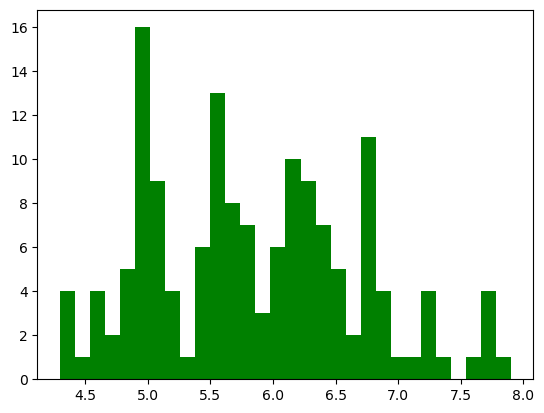

In [5]:
import matplotlib.pyplot as plt
plt.hist(iris_df.iloc[:,0],30,color='g');   

### 定量数据：正态分布检验


In [6]:
import scipy
scipy.stats.normaltest(iris_df.iloc[:,0],axis = 0) 
#每个检验都会返回一个统计量和一个p值。
# 如果p值大于你选择的显著性水平（通常是0.05），
# 那么你没有足够的证据拒绝数据来自正态分布的零假设。

NormaltestResult(statistic=5.735584236235733, pvalue=0.05682424941067306)

### 定性数据分布分析


In [7]:
iris_df.target.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

<Axes: ylabel='count'>

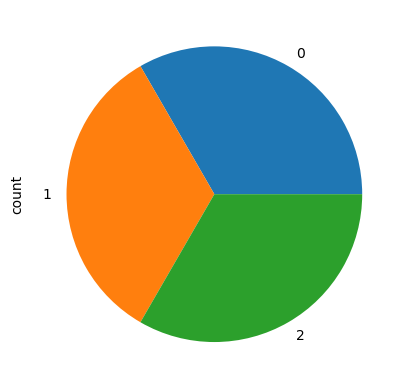

In [8]:
iris_df.target.value_counts().plot(kind = 'pie')

## 5.1.2 统计量分析

### 集中趋势分析Central tendency analysis
- 均值，中位数

In [9]:
iris_df.iloc[:,0].mean()  #均值

5.843333333333334

In [10]:
iris_df.iloc[:,0].median()  #中位数
iris_df.iloc[:,0].quantile()

5.8

### 离中趋势分析Dispersion tendency analysis  
- 标准差，四分位距

In [11]:
iris_df.iloc[:,0].std()

0.8280661279778629

In [12]:
iris_df.iloc[:,0].quantile([0.25,0.75])

0.25    5.1
0.75    6.4
Name: sepal length (cm), dtype: float64

In [13]:
# 四分位距
iris_df.iloc[:,0].quantile([0.75]).loc[0.75]-iris_df.iloc[:,0].quantile([0.25]).loc[0.25]

1.3000000000000007

In [14]:
iris_df.iloc[:,0].describe()

count    150.000000
mean       5.843333
std        0.828066
min        4.300000
25%        5.100000
50%        5.800000
75%        6.400000
max        7.900000
Name: sepal length (cm), dtype: float64

In [15]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 5.1.3 相关分析
- 单个图
- 图矩阵
- 相关系数—Pearson
    1. 两个变量间有线性关系
    2. 均是连续变量
    3. 变量均符合正态分布,且二元分布也符合正态分布
    4. 两个变量独立
    

In [16]:
iris_df.iloc[:,[0,1,4]].corr().round(2)

,sepal length (cm),sepal width (cm),target
sepal length (cm),1.00,-0.12,0.78
sepal width (cm),-0.12,1.00,-0.43
target,0.78,-0.43,1.00


In [17]:
iris_df['target'].corr(iris_df.iloc[:,0])

0.7825612318100819

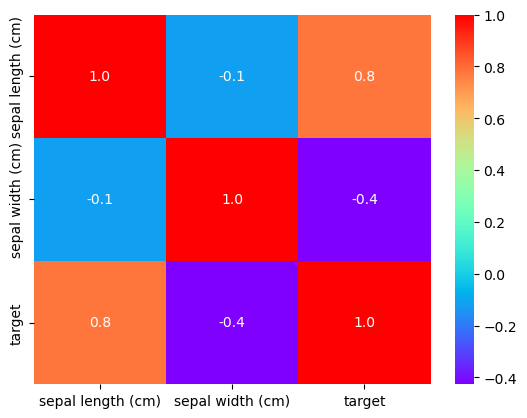

In [18]:
# 热力图
import seaborn as sns
sns.heatmap(iris_df.iloc[:,[0,1,4]].corr(),
            annot=True, fmt='.1f', cmap='rainbow');

                   sepal length (cm)  sepal width (cm)    target
sepal length (cm)           1.000000         -0.117570  0.782561
sepal width (cm)           -0.117570          1.000000 -0.426658
target                      0.782561         -0.426658  1.000000


<Axes: >

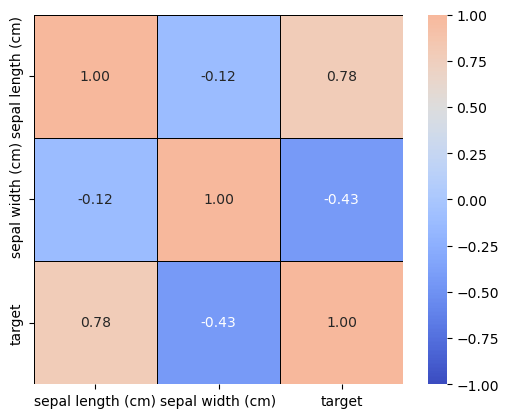

In [19]:
cor = iris_df.iloc[:,[0,1,4]].corr(method="pearson")
print(cor)

sns.heatmap(cor,
             # 显示数据值
             annot=True,
             # 颜色映射的中心值为 0.5
             center=0.5,
             # 当 annot 为 True 时，数值格式两位小数浮点数
             fmt='.2f',
             # 单元格之间分隔线的宽度为 0.5
             linewidth=0.5,
             # 单元格之间分隔线的颜色为黑色
             linecolor='black',
             # 颜色映射的最小值为 -1
             vmin=-1,
             # 颜色映射的最大值为 1
             vmax=1,  
             xticklabels=True,
             yticklabels=True,      
             # 每个单元格为正方形
             square=True,
             # 在热力图旁边显示颜色条
             cbar=True,
             # coolwarm方案（蓝色到红色渐变）
             cmap='coolwarm')


## 5.2 基于PANDAS的 数据统计与分析
## 5.2.1 简单筛选与统计


#### 筛选
1. 比较运算符对单个或多个列进行筛选：假设变量 a 为 10 ，变量 b 为 20
2. 逻辑运算符 & （与）、 | （或）和 ~ （非）组合条件，
   - 例如： 
      - df_filtered = df[(df['column1'] > value1) & (df['column2'] == value2)] # 筛选出满足两个条件的行
      - df_filtered = df[(df['column'] > value1) | (df['column'] < value2)] # 筛选出满足任一条件的行
      - df_filtered = df[~(df['column'] == value)] # 筛选出 'column' 不等于 value 的行
3. loc 和 iloc 方法
   - loc 是基于标签（ index 名称或索引位置）进行选择，可以结合布尔条件，
      - 例如：df_filtered = df.loc[df['column'] > value, :] # 根据指定列条件筛选所有列

   - iloc 是基于整数索引位置进行选择，不适用于布尔索引，
      - 例如：df_filtered = df.iloc[indices] # 筛选特定行索引位置的行

4. isin 方法
   - 对于类别型数据，筛选出具有特定值的行，
      - 例如：df_filtered = df[df['column'].isin(list_of_values)] # 筛选出 'column' 列包含在 list_of_values 中的行 

5. str.contains 方法
   - 主要用于对 Series 或 DataFrame 的字符串类型列进行基于正则表达式的筛选。该方法会返回一个布尔型Series ，可以进一步用于筛选满足条件的行。
      - 例如：df_filtered = df[df['column']. str.contains('attribute’)] # 筛选出 'column' 列包含 attribute 的行

#### 排序
1. sort_values 方法用于对 DataFrame 或 Series 按照指定列（对于DataFrame ）或索引（对于 Series ）进行排序。它可以实现升序或降序排列，并且支持多个排序键和层次排序。

  - 例如： df.sort_values('score', ascending=False, inplace=True,
                        ignore_index=True) 
  对 'score' 列进行降序排序， 并忽略索引，将排序后的结果直接赋值给原数据框

  - 常用参数：
    - by: 必需参数，可以是一个列名或者列名的列表，用来指定排序依据的列。
    - ascending:可选参数，默认为 True ，表示升序排序；如果设置为 False ，则会进行降序排序。 
    - inplace: 布尔值，表示是否在原地修改DataFrame。默认为False，则返回一个新的排序后的DataFrame。如果为True，则原地修改并返回None

In [20]:
import pandas as pd
djidf = pd.read_csv ('../data/djidf.csv',encoding='gbk')                           
djidf                     

,code,price
0,FLWS,33.48
1,VCVC,9.89
2,TXG,143.88
3,YI,10.86
4,YQ,4.75
5,ATNF,7.57
6,BCOW,14.09
7,ONEM,32.98
8,FCCY,19.98
9,SRCE,48.99


In [21]:
# 求道指成分股中所有股票最近一次成交价的均值
djidf.price.mean() 

30.025714285714287

In [22]:
# 求道指成分股中所有股票最近一次成交价大于等于25的公司名
djidf[djidf.price>=25].code
# or
djidf[djidf.price>=25]['code']

0     FLWS
2      TXG
7     ONEM
9     SRCE
12    TWOU
Name: code, dtype: object

In [23]:
# 求道指成分股中股票最近一次成交价大于等于100或小于等于10的公司信息。
djidf[(djidf.price >= 100) | (djidf.price <= 10)]

,code,price
1,VCVC,9.89
2,TXG,143.88
4,YQ,4.75
5,ATNF,7.57
11,ADER,9.64


In [24]:
# 按最近一次成交价 对道指成分股股票进行排序。根据排序结果列出前三甲公司名。
tempdf = djidf.sort_values(by = 'price', ascending = False)
tempdf[:3]['code']
# or
tempdf[:3].code
# or
tempdf.head(3).code

2      TXG
9     SRCE
12    TWOU
Name: code, dtype: object

In [25]:
quotesdf = pd.read_csv('../data/quotesdf.csv',index_col=0) # 第一列为索引
quotesdf
# quotesdf.index

,open,high,low,close,volume
2020-05-19,88.419998,89.839996,86.610001,87.260002,4920600
2020-05-20,89.180000,91.339996,88.769997,90.730003,5218500
2020-05-21,90.110001,91.430000,89.120003,89.830002,6241900
2020-05-22,89.709999,89.949997,88.209999,89.330002,3734500
2020-05-26,93.940002,95.570000,92.889999,94.320000,6559400
...,...,...,...,...,...
2021-05-12,154.720001,155.899994,152.070007,152.300003,3487400
2021-05-13,152.410004,154.809998,151.809998,154.080002,2269700
2021-05-14,155.389999,157.940002,154.529999,157.149994,1892700
2021-05-17,157.050003,157.380005,155.880005,156.860001,1541400


In [26]:
quotesdf.index = pd.to_datetime(quotesdf.index)
quotesdf.index

DatetimeIndex(['2020-05-19', '2020-05-20', '2020-05-21', '2020-05-22',
               '2020-05-26', '2020-05-27', '2020-05-28', '2020-05-29',
               '2020-06-01', '2020-06-02',
               ...
               '2021-05-05', '2021-05-06', '2021-05-07', '2021-05-10',
               '2021-05-11', '2021-05-12', '2021-05-13', '2021-05-14',
               '2021-05-17', '2021-05-19'],
              dtype='datetime64[ns]', length=252, freq=None)

In [27]:
# 统计美国运通公司2020年度9月份的股票开盘天数。
tempdf= quotesdf[
  (quotesdf.index >='2020-09-01') 
  & (quotesdf.index <='2020-09-30')]
# or
tempdf = quotesdf.loc['2020-09']
# or
tempdf = quotesdf[
  (quotesdf.index.year == 2020) 
  & (quotesdf.index.month == 9)]
len(tempdf)

21

In [28]:
#统计美国运通公司近一年股票涨和跌分别的天数。
len(quotesdf[quotesdf.close > quotesdf.open])  #涨的天数

139

In [29]:
len(quotesdf)-139  #跌的天数。

113

In [30]:
# np.diff 函数用于计算数组的一阶差分，即连续元素之间的差异。
# 对于一维数组，np.diff 返回相邻元素的差值。
# np.sign 函数可以返回给定数值的符号。
# 对于数组中的每个元素，np.sign 返回以下值之一：
# -1 如果元素是负数；0 如果元素是零；1 如果元素是正数
# 这里结合使用 np.diff 和 np.sign，可以确定价格变动的方向。
# 如果价格上升，则返回的值为正；如果价格下降，则为负；如果价格不变，则为零。

# 统计美国运通公司近一年相邻两天收盘价的涨跌情况。
status = np.sign(np.diff(quotesdf.close))
status

array([ 1., -1., -1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,
       -1., -1., -1.,  1.,  1.,  1., -1., -1., -1., -1., -1., -1.,  1.,
       -1.,  1.,  1., -1.,  1.,  1., -1., -1., -1.,  1.,  1.,  1.,  1.,
       -1., -1., -1.,  1.,  1.,  1., -1.,  1., -1.,  1., -1., -1.,  1.,
       -1.,  1.,  1.,  1.,  1.,  1., -1., -1., -1., -1., -1.,  1., -1.,
       -1.,  1., -1., -1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1.,  1.,
       -1.,  1.,  1., -1., -1., -1., -1., -1.,  1., -1., -1.,  1.,  1.,
       -1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1., -1., -1.,
        1., -1.,  1., -1.,  1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,
        1.,  1., -1.,  1., -1., -1., -1.,  1.,  1., -1., -1., -1., -1.,
        1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1., -1., -1.,  1.,
       -1., -1.,  1., -1., -1., -1., -1., -1.,  1.,  1.,  1., -1.,  1.,
        1., -1.,  1.,  1., -1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,
       -1., -1., -1., -1., -1.,  1., -1.,  1.,  1., -1.,  1.,  1

In [31]:
len(status[status==1])# 收盘价涨

135

In [32]:
len(status[status==-1])  # 收盘价跌

116

## 5.2.2 分组与聚合
1. groupby方法
- 可以根据索引或字段对数据进行分组。
- 格式为：df.groupby(by=None, axis=0, level=None, as_index=True, sort=True, group_keys=True, squeeze=False, **kwargs)
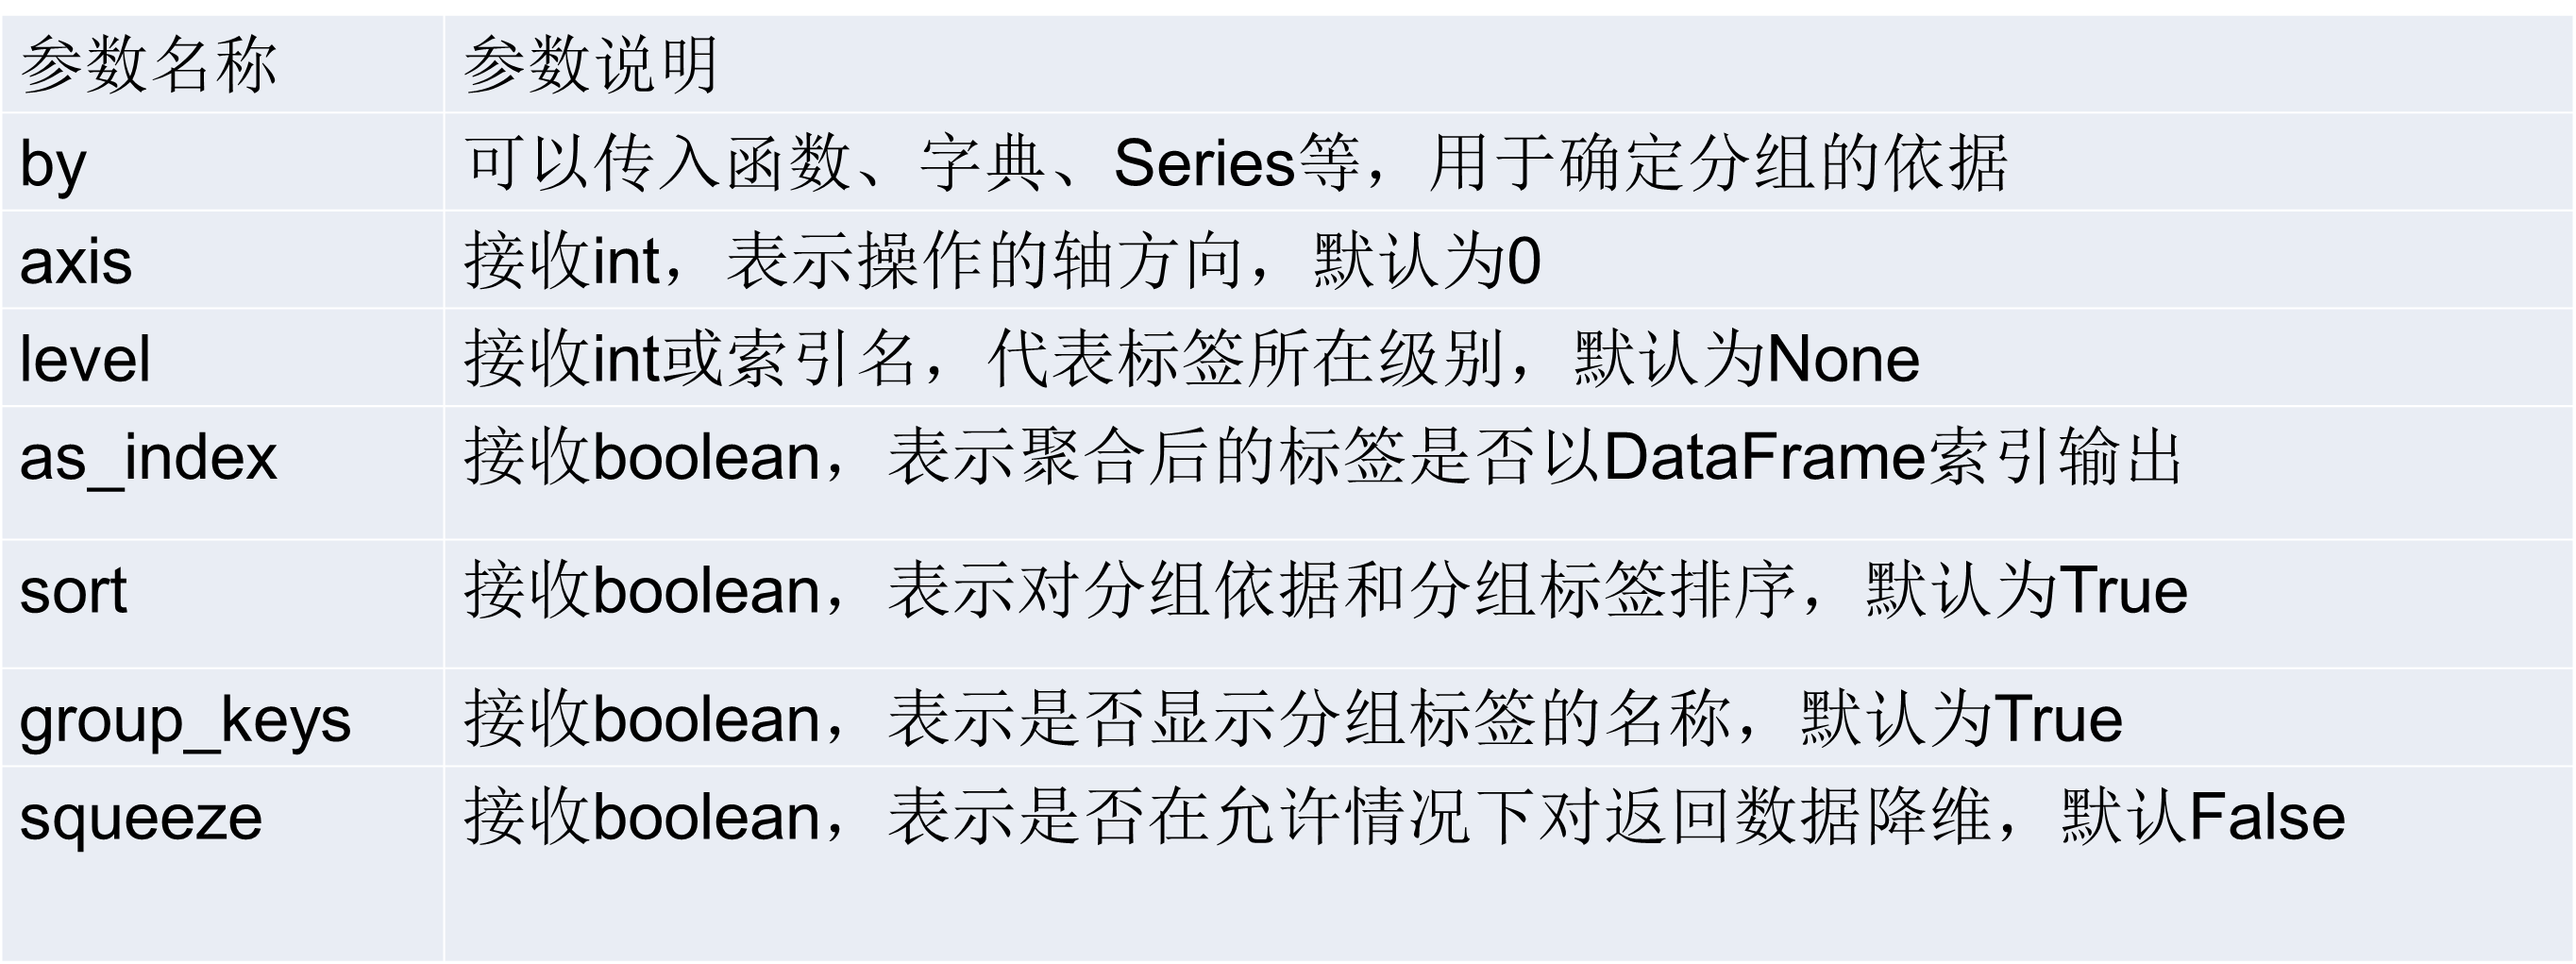
2. 使用agg方法聚合数据
- agg、aggregate方法都支持对每个分组应用某个函数，包括Python内置函数或自定义函数。同时，这两个方法也能够直接对DataFrame进行函数应用操作。
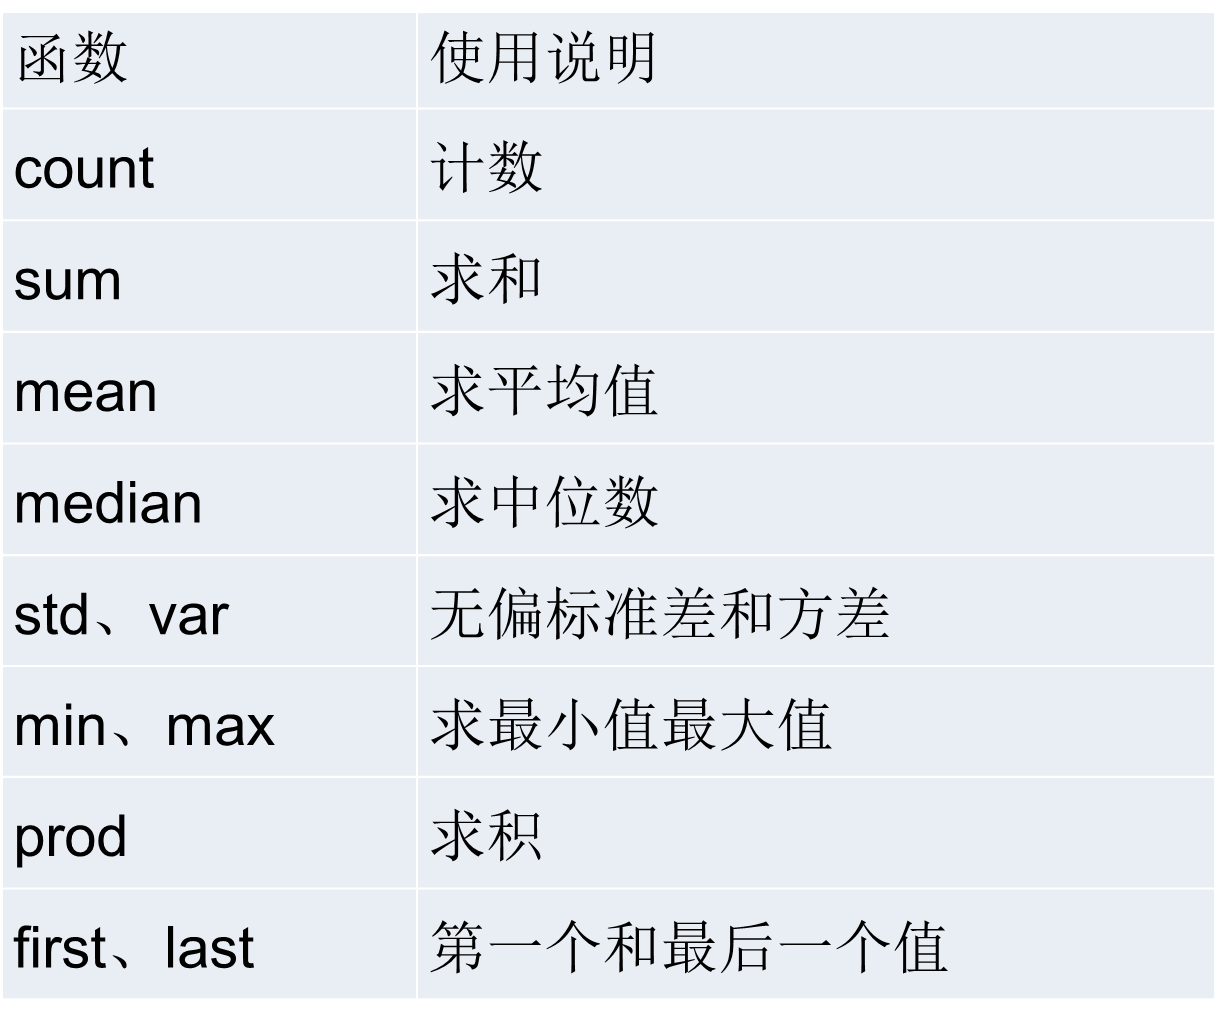
3. apply 方法用于对DataFrame的行或列应用一个函数。
- 基本用法如下：df.apply(函数, axis=0/1)
- apply 结合 lambda 函数的应用:
  - lambda 是 Python 中创建匿名函数的一种方式，通常与 apply()等函数一起使用来快速定义简单的单行函数。通过apply()用于应用自定义函数到整个数据集的每一行或每一列上，

  - 例如:df['new_column'] = df['existing_column'].apply(lambda x:x*2)# 遍历 existing_column 列的数据都乘以2

In [33]:
# 统计近一年美国运通公司每个月的股票开盘天数
month = quotesdf.index.month
quotesdf.groupby(month).count()['open']
# or
quotesdf.groupby(month).apply(len)

1     19
2     19
3     23
4     21
5     20
6     22
7     22
8     21
9     21
10    22
11    20
12    22
dtype: int64

In [34]:
#for k,data in quotesdf.groupby(month):
#    print(k)
#    print(data)

In [35]:
import numpy as np
quotesdf.loc[:, ['close', 'open']].apply(np.int32)# 转化为整数类型

,close,open
2020-05-19,87,88
2020-05-20,90,89
2020-05-21,89,90
2020-05-22,89,89
2020-05-26,94,93
...,...,...
2021-05-12,152,154
2021-05-13,154,152
2021-05-14,157,155
2021-05-17,156,157


In [36]:
quotesdf.loc[:, ['close', 'open']].apply(np.mean)


close    116.712976
open     116.635516
dtype: float64

In [37]:
quotesdf.groupby(month)['close'].mean()
# or
quotesdf.groupby(month)['close'].apply(np.mean)

1     121.584211
2     129.196841
3     143.260435
4     148.179048
5     130.795000
6     101.819091
7      94.803182
8      98.619525
9     101.873809
10    101.303182
11    111.188500
12    119.804092
Name: close, dtype: float64